# Task 2 — SVM (RBF Kernel)

**Name:** Abdlrhman Hisham Ismail · **ID:** AI2617

Train an SVM with **`kernel="rbf"`** (Gaussian Radial Basis Function) on the same wine dataset.


In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if "Task" in Path.cwd().name else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
)

from data_utils import load_wine_binary, dataset_info

print(dataset_info())
X_train, X_test, y_train, y_test = load_wine_binary()
print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Red Wine Quality (UCI / Kaggle) — binary label: good wine if quality >= 6. Features: fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free/total sulfur dioxide, density, pH, sulphates, alcohol.
Train: (1199, 11) | Test: (400, 11)


In [2]:
svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)),
])

svm_rbf.fit(X_train, y_train)
y_tr = svm_rbf.predict(X_train)
y_te = svm_rbf.predict(X_test)

print("=== SVM RBF ===")
print(f"Train Acc={accuracy_score(y_train, y_tr):.4f}  F1={f1_score(y_train, y_tr):.4f}")
print(f"Test  Acc={accuracy_score(y_test, y_te):.4f}  F1={f1_score(y_test, y_te):.4f}")
print("\nTest classification report:")
print(classification_report(y_test, y_te, target_names=["bad", "good"]))

n_sv = svm_rbf.named_steps["clf"].n_support_
print(f"Support vectors per class: {n_sv} (total={n_sv.sum()})")


=== SVM RBF ===
Train Acc=0.7998  F1=0.8113
Test  Acc=0.7550  F1=0.7644

Test classification report:
              precision    recall  f1-score   support

         bad       0.72      0.77      0.74       186
        good       0.79      0.74      0.76       214

    accuracy                           0.76       400
   macro avg       0.75      0.76      0.75       400
weighted avg       0.76      0.76      0.76       400

Support vectors per class: [364 368] (total=732)


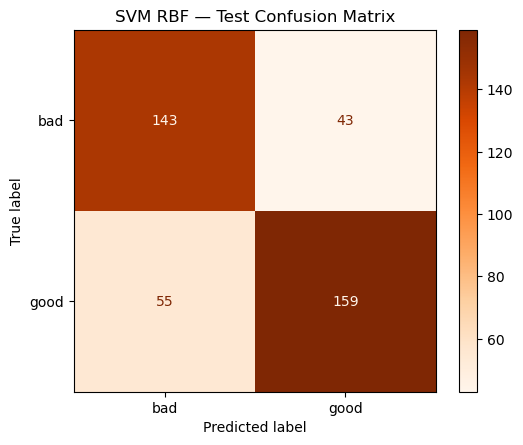

In [3]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_te, display_labels=["bad", "good"], ax=ax, cmap="Oranges"
)
ax.set_title("SVM RBF — Test Confusion Matrix")
fig.tight_layout()
fig.savefig("plots/svm_rbf_confusion.png", dpi=150)
plt.show()

pd.DataFrame([{
    "kernel": "rbf",
    "C": 1.0,
    "gamma": "scale",
    "train_acc": accuracy_score(y_train, y_tr),
    "train_f1": f1_score(y_train, y_tr),
    "test_acc": accuracy_score(y_test, y_te),
    "test_f1": f1_score(y_test, y_te),
    "n_support_vectors": int(n_sv.sum()),
}]).to_csv("results_svm_rbf.csv", index=False)


## Notes

The **RBF kernel** \(k(x, x') = \exp(-\gamma\|x-x'\|^2)\) maps samples into an infinite-dimensional feature space, allowing **non-linear** decision boundaries.  
Compared with linear SVM, RBF often fits complex patterns better but needs careful `C` / `gamma` tuning and may use more support vectors.
